# Computer Vision - Part 10

### Mobile Robot Kinematics

**Three Families of Mobile Robots**

1. **Differential Drive Robots**: These robots have two independently driven wheels on either side of the robot. They can move forward, backward, and turn by varying the speed of each wheel.

2. **Omnidirectional Robots**: These robots have wheels that can move in any direction, allowing for more complex movements such as strafing and rotating in place.

3. **Ackermann Steering Robots**: These robots have a steering mechanism similar to that of a car, where the front wheels can turn to steer the robot while the rear wheels provide propulsion.

**The Unicycle Model**
The unicycle model is a simplified representation of a mobile robot that captures its essential kinematic behavior. It assumes that the robot has a single point of contact with the ground and can move in any direction. The state of the robot is typically represented by its position (x, y) and orientation (theta). The control inputs are the linear velocity (v) and angular velocity (omega).
The kinematic equations for the unicycle model are as follows:

```dx/dt = v * cos(theta)
dy/dt = v * sin(theta)
dtheta/dt = omega
```

Where:
- `dx/dt`: The rate of change of the robot's x-coordinate.
- `dy/dt`: The rate of change of the robot's y-coordinate.
- `dtheta/dt`: The rate of change of the robot's orientation.
- `v`: The linear velocity of the robot.
- `omega`: The angular velocity of the robot.

### 1. Writing `unicycle_step`

This is the fundamental building block for all mobile robot trajectory simulation Implement a single Euler integration step for the unicycle model. The function should take in the current state of the robot, the control inputs, and the time step, and return the new state of the robot after applying the control inputs for the given time step.

```python

In [1]:
import numpy as np

In [2]:
def unicycle_step(x, y, th, v, w, dt):
    x_new = x + v * np.cos(th) * dt
    y_new = y + v * np.sin(th) * dt
    th_new = th + w * dt
    return x_new, y_new, th_new

In [4]:
'''Inputs:
+ Current state: (x, y, θ)
+ Control commands: v (m/s), ω (rad/s)
+ Time step: dt (seconds)
'''

current_state = (0.0, 0.0, 0.0)  # (x, y, θ)
control_commands = (1.0, 0.5)  # (v, ω)
time_step = 0.1  # dt
new_state = unicycle_step(*current_state, *control_commands, time_step)

'''
Output
+ New state (x_new, y_new, θ_new)
+ Uses first-order Euler integration
'''
print("New state:", new_state)

New state: (0.1, 0.0, 0.05)


### 2. Simulating Basic Unicycle Trajectories

Use unicycle_step in a loop and plot the resulting (x, y) trajectory. Explore three fundamental cases:

- **Case 1: Straight Line**

    `v = const`, `ω = 0`.  Robot moves in a straight line. Verify `x(t) = x₀ + vt cosθ₀`.

- **Case 2: Circle**

    `v = const`, `ω = const ≠ 0`.  Robot traces a circle of radius `R = v/ω`. Verify analytically.

- **Case 3: Free Trajectory**

    `v(t)`, `ω(t)` time-varying. Try sinusoidal `ω(t)` for a slalom path, or step changes for a zig-zag.

In [5]:
# Here is the simulation scaffold. Change vand w to explore different trajectory shapes:
dt = 0.05 # time step (seconds)
steps = 400 # total simulation steps
x, y, th = 0.0, 0.0, 0.0
traj = []
for k in range(steps):
    t = k * dt
    v = 0.2 # try changing this
    w = 0.5 # try 0, 0.5, -0.3, sin(t)
    x, y, th = unicycle_step(x, y, th, v, w, dt)
    traj.append((x, y))

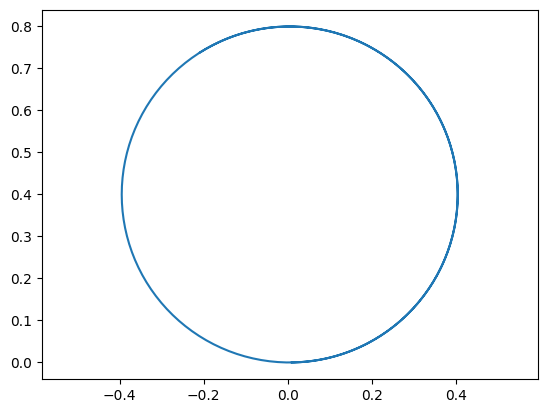

In [ ]:
# Plot trajectory
import matplotlib.pyplot as plt

# Always use plt.axis('equal')so circles appear as circles, not ellipses.
xs, ys = zip(*traj)
plt.plot(xs, ys); plt.axis('equal'); plt.show()

### 3. Implementing `diff_drive_step`

Differential drive is simply a physical realization of the unicycle model. Implement it by converting wheel speeds to unicycle inputs and calling `unicycle_step`:

In [7]:
'''
- W = track width in meters (e.g. 0.3 m for Turtlebot). This is the only hardware-specific parameter needed.

- diff_drive_step is a thin wrapper around unicycle_step. This reveals that diff-drive isa unicycle 
— just expressed in wheel- speed coordinates.

'''

def diff_drive_step(x, y, th, v_L, v_R, W, dt):
    v = (v_R + v_L) / 2.0
    w = (v_R - v_L) / W
    return unicycle_step(x, y, th, v, w, dt)

In [8]:
x, y, th = 0.0, 0.0, 0.0
W = 0.3 # track width (meters)
v_L, v_R = 0.2, 0.3 # left and right wheel speeds (m/s)
dt = 0.1 # time step (seconds)
new_state = diff_drive_step(x, y, th, v_L, v_R, W, dt)
print("New state:", new_state)

New state: (0.025, 0.0, 0.033333333333333326)


### 4. Diff-Drive Trajectory Simulation

Set `W = 0.3` m and simulate these configurations. Compare the result with the equivalent unicycle `(v, ω)` intuitively.

- **Straight Line: `v_L = v_R = 0.2`**

  `ω = 0` → robot drives straight. Equivalent to unicycle with `v = 0.2`, `ω = 0`.

- **Spin in Place: `v_L = −v_R = 0.1`**

  `v = 0`, `ω = 2v_L/W` → pure rotation. Only possible in diff-drive
  (not Ackermann)!

- **Circle (Arc): `v_L = 0.1`, `v_R = 0.3`**

  `v = 0.2`, `ω = 0.2/W = 0.667 rad/s` → circular arc curving left. 

- **Pivot on Wheel: `v_L = 0`, `v_R = 0.2`**

  `v = 0.1`, `ω = 0.2/W = 0.667 rad/s` → robot pivots around the stationary left wheel. Tight turn.

In [9]:
W = 0.3
# Straight line
v_L, v_R = 0.2, 0.2
# Circle
v_L, v_R = 0.2, 0.3
# In-place rotation
v_L, v_R = -w*W/2, w*W/2
# Pivot around left wheel
v_L, v_R = 0.0, w*W
# Try other trajectories by changing v_L and v_R as functions of time, e.g.:
# v_L = 0.2 + 0.1 * np.sin(t)
# v_R = 0.2 + 0.1 * np.cos(t)
# Compare the result with the equivalent unicycle (v, ω) intuitively.
straight_line = diff_drive_step(x, y, th, 0.2, 0.2, W, dt)
circle = diff_drive_step(x, y, th, 0.2, 0.3, W, dt)
in_place_rotation = diff_drive_step(x, y, th, -w*W/2, w*W/2, W, dt)
pivot = diff_drive_step(x, y, th, 0.0, w*W, W, dt)
print("Straight line:", straight_line)
print("Circle:", circle)
print("In-place rotation:", in_place_rotation)
print("Pivot:", pivot)

Straight line: (0.020000000000000004, 0.0, 0.0)
Circle: (0.025, 0.0, 0.033333333333333326)
In-place rotation: (0.0, 0.0, 0.05)
Pivot: (0.0075, 0.0, 0.05)


### 5. Basic Path-Following for Unicycle

Define a reference path (circle, sine curve, or straight line). At each time step, compute the heading error $e_θ$ between the robot's current heading and the direction to the look-ahead point on the path.

Simple Proportional Controller

$$v \approx const \quad (e.g., 0.2)$$
$$\omega \approx k \cdot e_\theta$$

Tune gain k and observe how quickly the robot converges to the path. Too large: oscillation. Too small: slow convergence.

In [10]:
# Circle
v_L, v_R = 0.2, 0.3
# Sine wave curve
v_L, v_R = 0.2 + 0.1 * np.sin(t), 0.2 + 0.1 * np.cos(t)
# Straight line
v_L, v_R = 0.2, 0.2
# At each time step, compute the heading error e_θ between the robot's current heading and the direction to the look-ahead point on the path.
# Simple Proportional Controller
v = 0.2 # constant forward speed
k = 1.0 # gain for heading correction
look_ahead_x, look_ahead_y = 1.0, 1.0 # example look-ahead point on the path
e_theta = np.arctan2(look_ahead_y - y, look_ahead_x - x) - th
w = k * e_theta
new_state = unicycle_step(x, y, th, v, w, dt)
print("New state:", new_state)

New state: (0.020000000000000004, 0.0, 0.07853981633974483)


## Reviewing Ackermann Steering Geometry

For a car turning a corner, all four wheels must rotate around a single instantaneous center of rotation (ICR). If they don't, tires slip and wear out quickly. 

Ackermann geometry ensures this by making the inner front wheel turn more sharply than the outer front wheel. In our kinematic model, we simplify this to a single effective steering angle δ.

Key Parameters

- **L — Wheelbase**: Distance from rear to front axle. Determines turning
sensitivity.

- **δ — Steering angle**: Effective front-wheel steering angle. Maps from SDK steering command. At this level, you don't need to compute inner/outer wheel angles separately — the bicycle model with one δ is sufficient.

- **v — Forward speed**: Maps from SDK throttle command.

### B1 - Writing `ackermann_step`

In [11]:
'''
The x and y equations are identical to the unicycle. Only θ_dot 
differs: instead of a free ω, it is (v/L) tan δ— coupled to speed and
steering geometry.
'''

def ackermann_step(x, y, th, v, delta, L, dt):
    x_new = x + v * np.cos(th) * dt
    y_new = y + v * np.sin(th) * dt
    th_new = th + (v / L) * np.tan(delta) * dt
    return x_new, y_new, th_new

In [12]:
L = 0.17 # wheelbase (meters)
delta_max = 0.5 # max steering angle (radians)
v_max = 1.0 # max speed (m/s)
print("Ackermann step:", ackermann_step(x, y, th, delta_max, v_max, L, dt))

Ackermann step: (0.05, 0.0, 0.4580610954867359)


### B2 — Simulating Jet Racer Trajectories

Use `ackermann_step` in a simulation loop and explore these fundamental patterns. Compare each with the equivalent unicycle trajectory.

- **Straight Line**: `δ = 0 → ω = 0`, car drives straight. Same as unicycle with `ω = 0`.

- **Constant Circle**: `δ = const ≠ 0 → constant ω = (v/L) tan δ` → circular arc. Radius `R = L / tan δ`.

- **Slalom**: `δ = δ_max · sin(t)` → oscillating steering → S-shaped slalom trajectory.


Notice: you cannot spin in place with Ackermann. The minimum turning radius is `R_min = L / tan(δ_max)`.

In [ ]:
# Straight line
delta = 0.0
# Circle
delta = 0.3
# Slaloming curve
delta = 0.3 * np.sin(t)
straight_line = ackermann_step(x, y, th, v_max, 0.0, L, dt)
circle = ackermann_step(x, y, th, v_max, 0.3, L, dt)
slaloming = ackermann_step(x, y, th, v_max, 0.3 * np.sin(t), L, dt)

print("Straight line:", straight_line)
print("Circle:", circle)
print("Slaloming curve:", slaloming)

Straight line: (0.1, 0.0, 0.0)
Circle: (0.1, 0.0, 0.18196249977036658)
Slaloming curve: (0.1, 0.0, 0.16116782571341037)


### B3 — Wrapping SDK Commands into Ackermann Simulation

Write a unified wrapper that accepts SDK-level commands and returns the next simulated state. This creates a hardware-in-the-loop compatible interface:

In [15]:
V_MAX = 1.0 # m/s
DELTA_MAX = 0.5 # rad (~28 degrees)
L = 0.17 # wheelbase in meters

def jet_racer_step(x, y, th, steering, throttle, dt):
    v = throttle * V_MAX
    delta = steering * DELTA_MAX
    return ackermann_step(x, y, th, v, delta, L, dt)

In [16]:
th = 0.0
steering = 0.5 # normalized steering input (-1 to 1)
throttle = 0.8 # normalized throttle input (0 to 1)
new_state = jet_racer_step(x, y, th, steering, throttle, dt)
print("Jet Racer step:", new_state)

Jet Racer step: (0.08000000000000002, 0.0, 0.12016090410401709)


Same function signature works for both simulation and real Jet Racer — just swap ackermann_step for actual SDK calls when on the real robot.

## Recap

We've implemented kinematic models for unicycle, differential drive, and Ackermann steering robots. We've simulated basic trajectories and explored how to wrap these models into a unified interface compatible with the Jet Racer SDK. This sets the stage for implementing more advanced control algorithms and eventually deploying on the real robot!